In [1]:
1+1

2

In [3]:
import os

print("현재 파이썬이 있는 위치:", os.getcwd())
print("이 폴더에 있는 파일 목록:", os.listdir())

현재 파이썬이 있는 위치: c:\workdir\space-cap\python-real-estate-analysis\notebooks
이 폴더에 있는 파일 목록: ['01_monthly_apt_trend.ipynb']


기본 데이터 로드 및 탐색 코드

In [4]:
import pandas as pd

# 1. 데이터 불러오기 (경로는 실제 파일 위치에 맞게 수정하세요)
file_path = '../data/월간 아파트 매매가격지수_20260408.xlsx'

# 엑셀 파일 읽기
# (csv로 변환된 파일이 있다면 pd.read_csv('파일명.csv')를 사용하셔도 됩니다)
df = pd.read_excel(file_path, engine='openpyxl')

# 2. 데이터 크기 확인 (행, 열 개수)
print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열\n")

# 3. 데이터 상위 5개 행 확인
display(df.head())

데이터 크기: 283행, 122열



,지역명,2016-03-01 09:00:52,2016-04-01 09:00:52,2016-05-01 09:00:52,2016-06-01 09:00:52,2016-07-01 09:00:52,2016-08-01 09:00:52,2016-09-01 09:00:52,2016-10-01 09:00:52,2016-11-01 09:00:52,...,2025-06-01 09:00:52,2025-07-01 09:00:52,2025-08-01 09:00:52,2025-09-01 09:00:52,2025-10-01 09:00:52,2025-11-01 09:00:52,2025-12-01 09:00:52,2026-01-01 09:00:52,2026-02-01 09:00:52,2026-03-01 09:00:52
0,전국,71.758939,71.780898,71.831308,71.895842,71.996097,72.098278,72.20752,72.41693,72.646086,...,89.457531,89.644476,89.671964,89.765775,90.019231,90.384846,90.669762,90.896435,91.264115,91.662871
1,서울,59.321167,59.391413,59.557238,59.794862,60.119852,60.456648,60.719965,61.155619,61.559396,...,96.898136,98.141807,98.7261,99.532833,100.983905,102.71722,103.80823,104.710833,106.109913,107.626057
2,강북14개구,59.638267,59.716303,59.838758,60.00187,60.250068,60.516119,60.722059,61.075993,61.483568,...,91.409396,92.357822,92.704463,93.309082,94.480477,95.927784,96.644737,97.360009,98.632676,100.317304
3,종로구,72.712626,72.790043,72.962052,73.042199,73.170641,73.357789,73.457794,73.69682,73.955765,...,102.532116,102.988925,103.178224,103.53731,103.806813,104.693372,105.540645,105.817513,106.887685,108.334017
4,중구,67.441888,67.441918,67.564474,67.832946,68.009125,68.271665,68.454258,68.747363,69.020794,...,99.237375,100.485793,100.794674,102.351724,104.150153,106.966954,109.1411,109.884284,111.114037,112.603016


1단계: 원하는 지역만 쏙 뽑아보기 (Filtering)

In [5]:
# '지역명' 컬럼에 어떤 지역들이 있는지 처음 20개만 확인
print("지역 목록 미리보기:")
print(df['지역명'].unique()[:20])
print("-" * 50)

# '서울' 지역 데이터만 필터링하기 (만약 '서울특별시'로 되어있다면 이름을 맞춰주세요)
# 엑셀 원본에 따라 '전국', '수도권', '강남구' 등으로 바꿔서 테스트해 보세요!
target_region = '서울' 
df_seoul = df[df['지역명'] == target_region]

display(df_seoul)

지역 목록 미리보기:
<StringArray>
[    '전국',     '서울', '강북14개구',    '종로구',     '중구',    '용산구',    '성동구',
    '광진구',   '동대문구',    '중랑구',    '성북구',    '강북구',    '도봉구',    '노원구',
    '은평구',   '서대문구',    '마포구', '강남11개구',    '양천구',    '강서구']
Length: 20, dtype: str
--------------------------------------------------


,지역명,2016-03-01 09:00:52,2016-04-01 09:00:52,2016-05-01 09:00:52,2016-06-01 09:00:52,2016-07-01 09:00:52,2016-08-01 09:00:52,2016-09-01 09:00:52,2016-10-01 09:00:52,2016-11-01 09:00:52,...,2025-06-01 09:00:52,2025-07-01 09:00:52,2025-08-01 09:00:52,2025-09-01 09:00:52,2025-10-01 09:00:52,2025-11-01 09:00:52,2025-12-01 09:00:52,2026-01-01 09:00:52,2026-02-01 09:00:52,2026-03-01 09:00:52
1,서울,59.321167,59.391413,59.557238,59.794862,60.119852,60.456648,60.719965,61.155619,61.559396,...,96.898136,98.141807,98.7261,99.532833,100.983905,102.71722,103.80823,104.710833,106.109913,107.626057


2단계: 데이터 구조 바꾸기 (가장 중요 ⭐️)

In [6]:
# melt를 이용해 가로로 긴 데이터를 세로로 변환
df_long = pd.melt(
    df_seoul, 
    id_vars=['지역명'],        # 유지할 기준 컬럼
    var_name='날짜',          # 컬럼 이름들이 모일 새로운 컬럼명
    value_name='매매가격지수'  # 실제 값들이 모일 새로운 컬럼명
)

# 날짜 컬럼을 진짜 '날짜(datetime)' 타입으로 변환
df_long['날짜'] = pd.to_datetime(df_long['날짜'], errors='coerce')

# 결과 확인
print("✅ 가로로 길었던 데이터가 세로로 변환되었습니다!")
display(df_long.head())

✅ 가로로 길었던 데이터가 세로로 변환되었습니다!


,지역명,날짜,매매가격지수
0,서울,2016-03-01 09:00:52,59.321167
1,서울,2016-04-01 09:00:52,59.391413
2,서울,2016-05-01 09:00:52,59.557238
3,서울,2016-06-01 09:00:52,59.794862
4,서울,2016-07-01 09:00:52,60.119852


선 그래프(Line Chart)

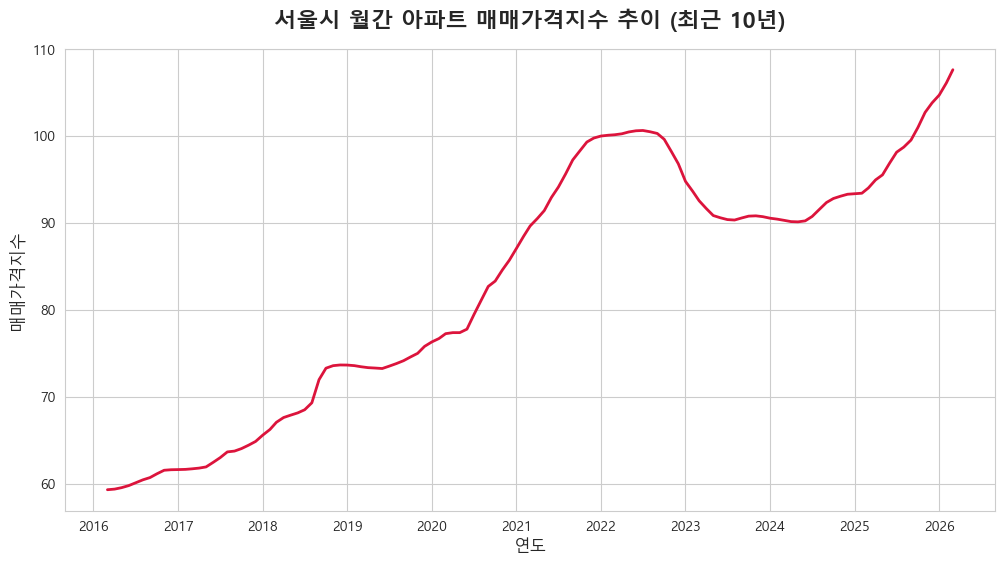

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정 (Windows 환경 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# (참고: 만약 Mac을 사용 중이시라면 위 'Malgun Gothic' 대신 'AppleGothic'을 입력하세요)

# 2. 그래프 크기 및 스타일 설정
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid") # 배경에 옅은 격자무늬 추가
plt.rcParams['font.family'] = 'Malgun Gothic' # seaborn 테마 적용 후 폰트 재설정

# 3. 선 그래프 그리기
# x축은 날짜, y축은 매매가격지수
sns.lineplot(data=df_long, x='날짜', y='매매가격지수', color='crimson', linewidth=2)

# 4. 제목 및 축 이름 설정
plt.title('서울시 월간 아파트 매매가격지수 추이 (최근 10년)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('연도', fontsize=12)
plt.ylabel('매매가격지수', fontsize=12)

# 5. 그래프 출력
plt.show()